In [1]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
from daemon_analysis_tools.io.csv_handler import load_and_process_csv
from daemon_analysis_tools.io.yaml_handler import save_answers_to_yaml, load_answers_from_yaml

Load and process data:
- Group answers by publisher and journal, trying to uniform names written in slightly different ways.
- Store in a DataFrame

In [3]:
grouped_questions = load_answers_from_yaml('../../data/processed/all_answers')

['../../data/processed/all_answers/ACS', '../../data/processed/all_answers/AIP', '../../data/processed/all_answers/APS', '../../data/processed/all_answers/Bentham Science', '../../data/processed/all_answers/Elsevier', '../../data/processed/all_answers/Frontiers', '../../data/processed/all_answers/IEEE', '../../data/processed/all_answers/MDPI', '../../data/processed/all_answers/Pleiades Publishing', '../../data/processed/all_answers/Springer Nature', '../../data/processed/all_answers/Taylor & Francis', '../../data/processed/all_answers/Wiley', '../../data/processed/all_answers/open journals']
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detect

In [4]:
tags_lookup = {"language understanding" : "Comprehension",
               "Language understanding" : "Comprehension",
               "difficulty in matching information and question" : "Comprehension",
               "Difficulty in matching information and question" : "Comprehension",
               "Selected answer is better interpretation of RDP." : "Comprehension",
               "Text missing and language understanding" : "Comprehension",
               "Text missing and Language understanding" : "Comprehension",
               "Text missing and  language understanding" : "Comprehension",
               "Text not found" : "Missed text",
               "Missed text." : "Missed text",
               "Text missing" : "Missed text",
               "Formatting inconsistent" : "Formatting",
               "Same answer but different wording." : "Formatting",
               "Inconsistent formatting." : "Formatting",
               None : "Consistent"}

inconsitencies_dict = {}

for publisher, journals in grouped_questions.items():
    n_question = 0
    inconsitencies = {"Consistent": 0}

    for journal, data in journals.items():
        for question, answer in data.items():
            n_question += 1

            if not answer.has_multiple_answers():
                continue

            if answer.has_discrepancies():
                discrepancy_reason = answer.discrepancy_reason

                if discrepancy_reason in tags_lookup:
                    discrepancy_reason = tags_lookup[discrepancy_reason] 

                if not discrepancy_reason in inconsitencies:
                    inconsitencies[discrepancy_reason] = 0
                
                inconsitencies[discrepancy_reason] += 1
            else:
                inconsitencies["Consistent"] += 1
    
    print(publisher, inconsitencies)
    inconsitencies_dict[publisher] = inconsitencies

ACS {'Consistent': 147, 'Missed text': 59, 'Comprehension': 11, 'Formatting': 9}
AIP {'Consistent': 215, 'Comprehension': 16, 'Missed text': 7}
APS {'Consistent': 205, 'Comprehension': 4}
False ['Research Data Policy (RDP) exists.', 'Research Data Policy (RDP) exists.'] 1
False ['Public data sharing on a FAIR repository not mentioned in RDP.', 'Public data sharing on a FAIR repository not mentioned in RDP.'] 1
False ['Required according to the RDP.', 'Required according to the RDP.'] 1
False ['Required data must be available prior to review process.', 'Required data must be available prior to review process.'] 1
False ['No mention of data/code licenses in RDP.', 'No mention of data/code licenses in RDP.'] 1
False ['Code sharing not mentioned.', 'Code sharing not mentioned.'] 1
False ['No mention of dependencies for research code.', 'No mention of dependencies for research code.'] 1
False ['No mention of a persistent identifier or specifying a version of developed code.', 'No mention of

Get a `dict` labeled by publisher names of `dict`s labeled by journal names of `dict`s of `Question` instances. The `.answer` attribute contains the answers given by the respondents and the explanations text to motivate it.

[156  59  11] ['Consistent', 'Missed text', 'Comprehension']
[215  16   7] ['Consistent', 'Comprehension', 'Missed text']
[205   4] ['Consistent', 'Comprehension']
[90 18  6] ['Consistent', 'Comprehension', 'Missed text']
[102  12  19] ['Consistent', 'Missed text', 'Comprehension']
[63 21 35] ['Consistent', 'Comprehension', 'Missed text']
[240  30] ['Consistent', 'Missed text']
[141 114  30] ['Consistent', 'Comprehension', 'Missed text']
[115  29  27] ['Consistent', 'Comprehension', 'Missed text']
[130  57   1] ['Consistent', 'Missed text', 'Rejected insider information']
[257  28] ['Consistent', 'Comprehension']
[167  75  43] ['Consistent', 'Missed text', 'Comprehension']
[10  8  1] ['Consistent', 'Missed text', 'Comprehension']


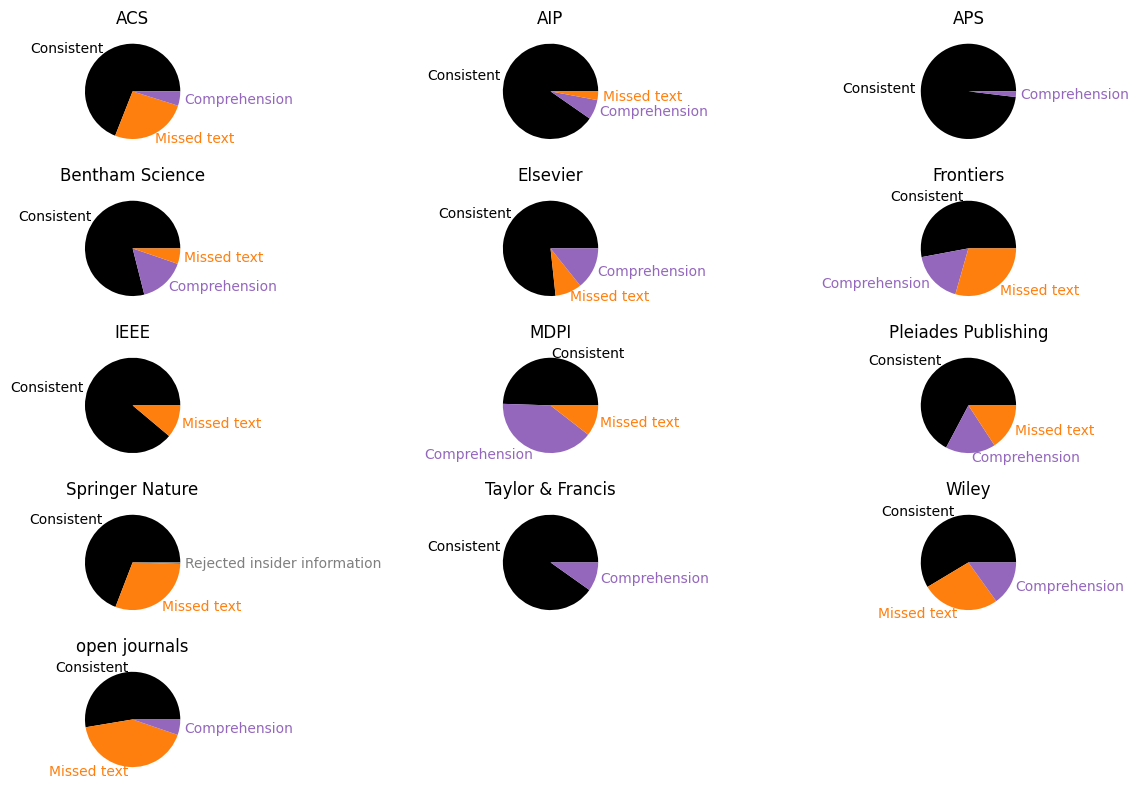

In [5]:
import numpy as np
from copy import deepcopy
from matplotlib import pyplot as plt

color_dict = {"Consistent" : "k",
          "Missed text" : "C1",
          "Comprehension" : "C4",
          "Rejected insider information" : "C7",

}

fig = plt.figure(figsize=(12, 8))

for ind, (publisher, data_0) in enumerate(inconsitencies_dict.items()):
    data = deepcopy(data_0)

    if "Formatting" in data:
        data["Consistent"] += data["Formatting"]
        data.pop("Formatting", None)

    y = np.array(list(data.values()))
    labels = list(data.keys())

    print(y, labels)

    w = 3
    h = int(np.ceil(len(inconsitencies_dict)/w))

    colors = []
    for l in labels:
        colors.append(color_dict[l])

    plt.subplot(h, w, ind+1)
    plt.title(publisher)
    _, texts = plt.pie(y, labels=labels, colors=colors)

    for text, color in zip(texts, colors):
        text.set_color(color)

plt.tight_layout()
fig.savefig("../../data/processed/inconsistencies.pdf")